In [1]:
import matplotlib.pyplot as plt 
import numpy as np 
import pandas as pd 
import seaborn as sbn 
import random 
from mpl_toolkits.mplot3d import axes3d
#% matplotlib inline

In [2]:
datasetcovid=pd.read_excel('dataset.xlsx')

In [3]:
pd.set_option('display.max_row',111)

In [4]:
#une nouvelle copie du dataset original
data_preproccessing=datasetcovid.copy()

In [5]:
# la 1ere de chose c'est de selectionner les variables qu'on a juge utiles dans le EDA
missing_rate=data_preproccessing.isna().sum(axis=0)/data_preproccessing.shape[0]
#creons la liste des variables les plus importantes
blood_columns2=list(data_preproccessing.columns[(missing_rate<0.9) & (missing_rate>0.88)])
viral_columns2=list(data_preproccessing.columns[(missing_rate<0.80) & (missing_rate>0.75)])
key_columns=['Patient age quantile','SARS-Cov-2 exam result']

In [6]:
data_preproccessing=data_preproccessing[key_columns + blood_columns2 + viral_columns2]

In [7]:
pd.set_option('display.max_column',data_preproccessing.shape[1])#permet d'afficher  colonne
data_preproccessing.head(5)

,Patient age quantile,SARS-Cov-2 exam result,Hematocrit,Hemoglobin,Platelets,Mean platelet volume,Red blood Cells,Lymphocytes,Mean corpuscular hemoglobin concentration (MCHC),Leukocytes,Basophils,Mean corpuscular hemoglobin (MCH),Eosinophils,Mean corpuscular volume (MCV),Monocytes,Red blood cell distribution width (RDW),Respiratory Syncytial Virus,Influenza A,Influenza B,Parainfluenza 1,CoronavirusNL63,Rhinovirus/Enterovirus,Coronavirus HKU1,Parainfluenza 3,Chlamydophila pneumoniae,Adenovirus,Parainfluenza 4,Coronavirus229E,CoronavirusOC43,Inf A H1N1 2009,Bordetella pertussis,Metapneumovirus,Parainfluenza 2
0,13,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,17,negative,0.236515,-0.02234,-0.517413,0.010677,0.102004,0.318366,-0.95079,-0.09461,-0.223767,-0.292269,1.482158,0.166192,0.357547,-0.625073,not_detected,not_detected,not_detected,not_detected,not_detected,detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected
2,8,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,15,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_detected,not_detected,not_detected,not_detected,not_detected,detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected


In [43]:
#import train_test_split depuis le module model selection.
from sklearn.model_selection import train_test_split
trainset,testset= train_test_split(data_preproccessing,test_size=0.2,random_state=10)
testset.head()

,Patient age quantile,SARS-Cov-2 exam result,Hematocrit,Hemoglobin,Platelets,Mean platelet volume,Red blood Cells,Lymphocytes,Mean corpuscular hemoglobin concentration (MCHC),Leukocytes,Basophils,Mean corpuscular hemoglobin (MCH),Eosinophils,Mean corpuscular volume (MCV),Monocytes,Red blood cell distribution width (RDW),Respiratory Syncytial Virus,Influenza A,Influenza B,Parainfluenza 1,CoronavirusNL63,Rhinovirus/Enterovirus,Coronavirus HKU1,Parainfluenza 3,Chlamydophila pneumoniae,Adenovirus,Parainfluenza 4,Coronavirus229E,CoronavirusOC43,Inf A H1N1 2009,Bordetella pertussis,Metapneumovirus,Parainfluenza 2
1583,2,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_detected,not_detected,not_detected,not_detected,detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected
4338,14,negative,1.586941,1.544059,0.33679,-0.662483,1.935561,0.497476,0.244149,0.826494,-0.529226,-0.762714,1.229322,-0.935433,-0.010138,-0.536617,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3052,13,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4153,11,positive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2270,9,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
trainset.iloc[:,1].value_counts(),testset.iloc[:,1].value_counts()
#le proportion de chaque cas et bien respectee apres le decoupage

(SARS-Cov-2 exam result
 negative    4069
 positive     446
 Name: count, dtype: int64,
 SARS-Cov-2 exam result
 negative    1017
 positive     112
 Name: count, dtype: int64)

In [45]:
 #creons une fonction qui permet de faire l'encodage sur le train et le test
def encodage(data_preproccessing):
    #remplacons nos variables qualitalives par les varables quantitatives
    code={'positive':1,'negative':0,'detected':1,'not_detected':0}
    for col in data_preproccessing.select_dtypes('object'):
        data_preproccessing[col]=data_preproccessing[col].map(code)
    return data_preproccessing

In [46]:
encodage(trainset).dtypes.value_counts()

float64    31
int64       2
Name: count, dtype: int64

In [47]:
trainset.drop(columns='SARS-Cov-2 exam result')

,Patient age quantile,Hematocrit,Hemoglobin,Platelets,Mean platelet volume,Red blood Cells,Lymphocytes,Mean corpuscular hemoglobin concentration (MCHC),Leukocytes,Basophils,Mean corpuscular hemoglobin (MCH),Eosinophils,Mean corpuscular volume (MCV),Monocytes,Red blood cell distribution width (RDW),Respiratory Syncytial Virus,Influenza A,Influenza B,Parainfluenza 1,CoronavirusNL63,Rhinovirus/Enterovirus,Coronavirus HKU1,Parainfluenza 3,Chlamydophila pneumoniae,Adenovirus,Parainfluenza 4,Coronavirus229E,CoronavirusOC43,Inf A H1N1 2009,Bordetella pertussis,Metapneumovirus,Parainfluenza 2
2822,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5242,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
329,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
491,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5589,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1180,14,-0.289922,-0.272964,0.387037,-0.886869,-0.56795,0.63394,0.044991,-0.676214,0.081693,0.596348,-0.076999,0.626871,-0.587929,-0.890442,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3441,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1344,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4623,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [48]:
trainset.dtypes.value_counts()

float64    31
int64       2
Name: count, dtype: int64

### faisons du feature_ing car lorsqu'on a creer la variale malade on a pu remarquer la difference des taux .eput etre en creant cette vartaible on aura une performance + elevee

In [49]:
def feature_engineering(dataframe):
    dataframe['est malade'] = dataframe[viral_columns2].sum(axis=1)>=1
    #eluminons toute les autres varables virarl
    dataframe=dataframe[key_columns + blood_columns2 + ['est malade'] ]

    return dataframe

In [50]:
# imputation
def imputation(dataframe):
    from sklearn.impute import SimpleImputer
    dataframe=encodage(dataframe)
    #dataframe.fillna(-999)
    #dataframe['']
    #return dataframe.fillna(value= {"{}".format(col): dataframe[col].mean() for col in list(dataframe.select_dtypes('float'))})#SimpleImputer().fit_transform(dataframe)
    return dataframe.dropna(axis='index')
    
def preprocessing(dataframe):
    dataframe=encodage(dataframe)
    #dataframe=feature_engineering(dataframe)
    dataframe=imputation(dataframe)
    print(dataframe.dtypes.value_counts())
    x,y=dataframe.drop(columns='SARS-Cov-2 exam result'),dataframe['SARS-Cov-2 exam result']
    print('la proportion cas apres le preprocessing est de: {} {}'.format(x.shape,y.value_counts()))
    return x,y

x_train,y_train=preprocessing(trainset)
x_test,y_test=preprocessing(testset)

float64    31
int64       2
Name: count, dtype: int64
la proportion cas apres le preprocessing est de: (292, 32) SARS-Cov-2 exam result
0    255
1     37
Name: count, dtype: int64
float64    31
int64       2
Name: count, dtype: int64
la proportion cas apres le preprocessing est de: (70, 32) SARS-Cov-2 exam result
0    57
1    13
Name: count, dtype: int64


In [51]:
data_=imputation(trainset)
data_

,Patient age quantile,SARS-Cov-2 exam result,Hematocrit,Hemoglobin,Platelets,Mean platelet volume,Red blood Cells,Lymphocytes,Mean corpuscular hemoglobin concentration (MCHC),Leukocytes,Basophils,Mean corpuscular hemoglobin (MCH),Eosinophils,Mean corpuscular volume (MCV),Monocytes,Red blood cell distribution width (RDW),Respiratory Syncytial Virus,Influenza A,Influenza B,Parainfluenza 1,CoronavirusNL63,Rhinovirus/Enterovirus,Coronavirus HKU1,Parainfluenza 3,Chlamydophila pneumoniae,Adenovirus,Parainfluenza 4,Coronavirus229E,CoronavirusOC43,Inf A H1N1 2009,Bordetella pertussis,Metapneumovirus,Parainfluenza 2
4226,16,0,-1.022356,-1.087492,-0.316424,0.010677,-1.061599,0.369540,-0.552476,0.884933,-0.529226,0.021361,-0.161278,0.306399,0.016125,-0.094334,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3411,11,0,-1.205464,-1.275460,1.567847,2.254541,-0.444537,-1.327740,-0.652057,2.162234,-0.529226,-1.546788,0.260116,-1.436172,-1.349562,3.532382,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4998,18,0,-1.800568,-1.902020,1.103060,-1.111256,-1.925487,0.071023,-1.050367,-0.420197,-0.223767,0.230447,-0.709090,0.807138,2.012129,2.470904,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2377,6,0,0.236515,0.353596,-0.442042,-0.999063,-0.109560,-1.694489,0.542882,0.036181,-1.140144,0.805435,-0.835508,0.626871,-1.008140,-0.094334,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1321,16,0,-0.061036,-0.398276,0.839262,-0.774677,-0.039039,0.949515,-1.349101,0.712400,-1.140144,-0.658171,-0.414114,-0.094192,-1.008140,0.082579,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232,14,0,1.632718,1.606716,-0.052626,-0.774677,1.336129,0.096611,0.244149,-0.545423,0.387152,0.282719,1.313601,0.166192,0.252494,-0.801985,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
62,11,0,0.740064,0.541564,-0.065188,0.683835,-0.215342,0.966573,-0.552476,0.350636,0.081693,1.328151,0.555092,1.808615,-0.088928,0.790231,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2700,9,0,0.579844,0.792188,-0.906829,-0.774677,0.172526,0.130727,0.941197,-0.467504,-0.223767,1.014521,0.512953,0.646902,1.408075,-0.182790,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
239,5,0,1.083393,1.481403,-0.555098,-0.662483,1.106935,0.147785,1.638245,-0.564902,-0.529226,0.439533,-0.076999,-0.314517,1.145443,-0.801985,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [52]:
x_train.dtypes.value_counts()

float64    31
int64       1
Name: count, dtype: int64

In [53]:
y_test.size

70

# Modelisation 

In [54]:
#creons un arbre de decision 
#importons les differents metriques
from sklearn.metrics import f1_score, confusion_matrix,classification_report
from sklearn.model_selection import learning_curve#permet de voir si notre modele est en over ou endre fitting
#model =DecisionTreeClassifier(random_state=0)
##utlisons randomforest
from sklearn.ensemble import RandomForestClassifier
#model= RandomForestClassifier(random_state=0)

from sklearn.tree import  DecisionTreeClassifier
from sklearn.feature_selection import SelectKBest,f_classif #c'est le test d'anova
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
model=make_pipeline(PolynomialFeatures(2),SelectKBest(f_classif,k=10),
                    RandomForestClassifier())
#le reglage des parrametre du modele on le faira dans la prochaine 

la metrique F1 permet d'avoir un bon appercu entre le rapport de la precision et la sensibilite(recall) .la precision et la sensibilte se sont des metriques qui permettent de mesurer les proportions erreurs de type 1 et de type 2(faut positive et faut negative) dans le dataset  

### Procedure d'evaluation

In [55]:
def evaluation(model):
    model.fit(x_train,y_train)
    score=model.score(x_train,y_train)
    y_prediction=model.predict(x_test)
    matrice_de_confusion=confusion_matrix(y_test,y_prediction)
    report=classification_report(y_test,y_prediction)
    print('la matrice de confusion \n {}'.format(matrice_de_confusion))
    print('{}'.format(report))
    
    #Essayons d'ameliorer le modele en tracant la courbe de validation enfin de bien comprendre notre modele.
    N,train_score,test_score=learning_curve(model,
                                            x_train,y_train,
                                           cv=4, scoring='f1',train_sizes=np.linspace(0.1,1,10))
    #tracons ls courbes
    plt.figure()
    plt.plot(N, train_score.mean(axis=1),color='b',label='le score sur le train')
    plt.plot(N, test_score.mean(axis=1),color='red',label='le score sur le test')
    plt.legend()

C:\Users\User\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [  0  19  24  30  32  51  56  57  58  62  64  82  87  93  95 112 117 123
 125 141 146 152 154 169 174 180 182 196 201 207 209 222 227 233 235 247
 252 258 260 271 276 282 284 294 299 305 307 316 321 327 329 337 342 348
 350 357 362 368 370 376 381 387 389 394 399 405 407 409 410 411 412 414
 415 416 418 419 420 421 422 423 424 426 427 428 429 430 431 432 433 435
 436 438 439 440 442 445 446 447 448 449 450 451 453 455 456 457 458 459
 460 461 462 463 464 465 466 467 468 469 471 472 474 475 476 477 478 479
 480 481 482 484 485 486 488 489 491 492 493 494 496 497 498 499 500 501
 503 504 505 507 508 509 510 511 512 513 514 515 516 517 518 519 520 521
 522 523 524 526 527 528 529 530 531 532 534 535 536 537 538 539 541 542
 543 544 545 547 548 549 550 552 553 554 555 556 557 559 560] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserW

la matrice de confusion 
 [[55  2]
 [ 5  8]]
              precision    recall  f1-score   support

           0       0.92      0.96      0.94        57
           1       0.80      0.62      0.70        13

    accuracy                           0.90        70
   macro avg       0.86      0.79      0.82        70
weighted avg       0.90      0.90      0.89        70



C:\Users\User\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [  0  19  20  22  23  24  25  26  27  28  30  32  48  51  52  54  55  56
  57  58  59  60  62  64  82  83  85  86  87  88  89  90  91  93  95 112
 113 115 116 117 118 119 120 121 123 125 141 142 144 145 146 147 148 149
 150 152 154 169 170 172 173 174 175 176 177 178 180 182 196 197 199 200
 201 202 203 204 205 207 209 222 223 225 226 227 228 229 230 231 233 235
 247 248 250 251 252 253 254 255 256 258 260 271 272 274 275 276 277 278
 279 280 282 284 294 295 297 298 299 300 301 302 303 305 307 316 317 319
 320 321 322 323 324 325 327 329 337 338 340 341 342 343 344 345 346 348
 350 357 358 360 361 362 363 364 365 366 368 370 376 377 379 380 381 382
 383 384 385 387 389 394 395 397 398 399 400 401 402 403 405 407 409 410
 411 412 413 414 415 416 417 418 419 420 421 422 423 424 426 427 428 429
 430 431 432 433 434 435 436 438 439 440 442 443 444 445 446 447 448 449
 450

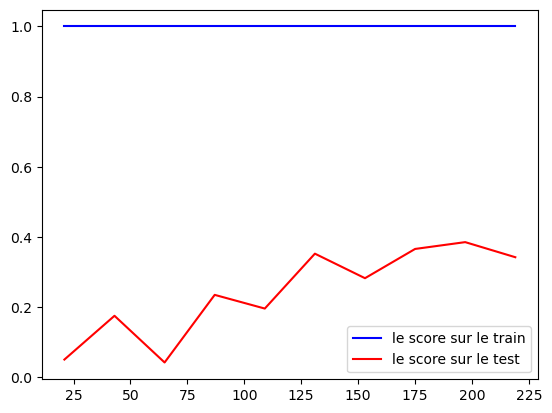

In [56]:
evaluation(model)

#utilisoons l'attribut futur importance du modele pour choisr les meilleurs variables pour le stimatuer choisit
print(model.feature_importances_ )#chaque valeur du array est assossier a une colonne
#on peut injecter tout ca dans un tableau df 
pd.DataFrame(model.feature_importances_,index=x_train.columns)[:5]

#tracons un colorbar pour voir plus clair
plt.figure(figsize=(12,10))
pd.DataFrame(model.feature_importances_,index=x_train.columns).plot.bar()

### utilisons un modele qui permet de lutter de facon + efficace  au probleme overfitting(modele regulariser ) en loccurence  . par ex le randomforest

le feature ingeneering n'a pas donne un bon resultat. car le modele tt au debut a un score plus elevee.

Essayons cette fois de supprimer qlq variable en dessous d'un certain seil en utilisant le selecteur select_from_model mais aussi on peut utiliser selctKbest().
Pour cela dans la partie modelisation definition un pepiline. Avec le feature_selection on voit que la performance du model augmente. le meilleur paramettre du kbest c,est quand K=5-4

une technique qui marche souvent bien c'est de faire une expenssion polynomiale suivit d'un pce ou kbest.
l'objectif est d'elevee chaque varable au carre par ex puis le multiplier avec les restes de variables.

on a pas fait de normalisation par c que on developpe des modeles basee sur des arbres de decision et ces genres de modele ne necessite pas de faire de  normalisation

 # randon state
https://www.web-dev-qa-db-fra.com/fr/python/quest-ce-que-random-state-dans-lexemple-sklearn.model-selection.train-test-split/837923694/

In [57]:
x=np.random.randint(0,10,(10,2))
x

array([[7, 2],
       [0, 1],
       [8, 1],
       [4, 7],
       [3, 3],
       [2, 1],
       [0, 9],
       [5, 9],
       [2, 8],
       [1, 6]])

In [58]:
PolynomialFeatures(2,include_bias=False).fit_transform(x)

array([[ 7.,  2., 49., 14.,  4.],
       [ 0.,  1.,  0.,  0.,  1.],
       [ 8.,  1., 64.,  8.,  1.],
       [ 4.,  7., 16., 28., 49.],
       [ 3.,  3.,  9.,  9.,  9.],
       [ 2.,  1.,  4.,  2.,  1.],
       [ 0.,  9.,  0.,  0., 81.],
       [ 5.,  9., 25., 45., 81.],
       [ 2.,  8.,  4., 16., 64.],
       [ 1.,  6.,  1.,  6., 36.]])

In [59]:
PolynomialFeatures(2,include_bias=True).fit_transform(x)

array([[ 1.,  7.,  2., 49., 14.,  4.],
       [ 1.,  0.,  1.,  0.,  0.,  1.],
       [ 1.,  8.,  1., 64.,  8.,  1.],
       [ 1.,  4.,  7., 16., 28., 49.],
       [ 1.,  3.,  3.,  9.,  9.,  9.],
       [ 1.,  2.,  1.,  4.,  2.,  1.],
       [ 1.,  0.,  9.,  0.,  0., 81.],
       [ 1.,  5.,  9., 25., 45., 81.],
       [ 1.,  2.,  8.,  4., 16., 64.],
       [ 1.,  1.,  6.,  1.,  6., 36.]])

In [60]:
dataframe=pd.DataFrame(data=PolynomialFeatures(2,include_bias=True).fit_transform(x),
                       index=pd.date_range(start='01.01.2022',periods=10))
dataframe['6']=dataframe.loc[:,2]*dataframe.loc[:,3]
dataframe

,0,1,2,3,4,5,6
2022-01-01,1.0,7.0,2.0,49.0,14.0,4.0,98.0
2022-01-02,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2022-01-03,1.0,8.0,1.0,64.0,8.0,1.0,64.0
2022-01-04,1.0,4.0,7.0,16.0,28.0,49.0,112.0
2022-01-05,1.0,3.0,3.0,9.0,9.0,9.0,27.0
2022-01-06,1.0,2.0,1.0,4.0,2.0,1.0,4.0
2022-01-07,1.0,0.0,9.0,0.0,0.0,81.0,0.0
2022-01-08,1.0,5.0,9.0,25.0,45.0,81.0,225.0
2022-01-09,1.0,2.0,8.0,4.0,16.0,64.0,32.0
2022-01-10,1.0,1.0,6.0,1.0,6.0,36.0,6.0


In [61]:
model.classes_

array([0, 1], dtype=int64)

In [62]:
x=np.random.randn(20,2)
x,PolynomialFeatures(2).fit_transform(x);

In [63]:
y=list(range(5))
y

[0, 1, 2, 3, 4]